# 02. DCGAN Results
Load trained checkpoints, visualize samples, run ablation analysis, compute FID.

In [1]:
import sys; sys.path.insert(0, '..')

import torch
import yaml
from pathlib import Path
from IPython.display import Image as IPImage

from src.models.dcgan import Generator, Discriminator
from src.utils.seed import set_seed
from src.utils.visualization import save_image_grid, plot_losses
from src.evaluation.fid import save_samples, compute_fid, save_real_samples
from src.data.preprocessing import get_cat_loader

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

with open('../configs/dcgan_config.yaml', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)
mc = cfg['model']

Device: cuda


In [2]:
CKPT = '../checkpoints/dcgan/ckpt_epoch0100.pt'
G = Generator(z_dim=mc['z_dim'], base_channels=mc['g_channels'],
              image_size=cfg['data']['image_size']).to(device)
state = torch.load(CKPT, map_location=device)
G.load_state_dict(state['G'])
G.eval()
print(f"Loaded checkpoint from epoch {state['epoch']}")

Loaded checkpoint from epoch 100


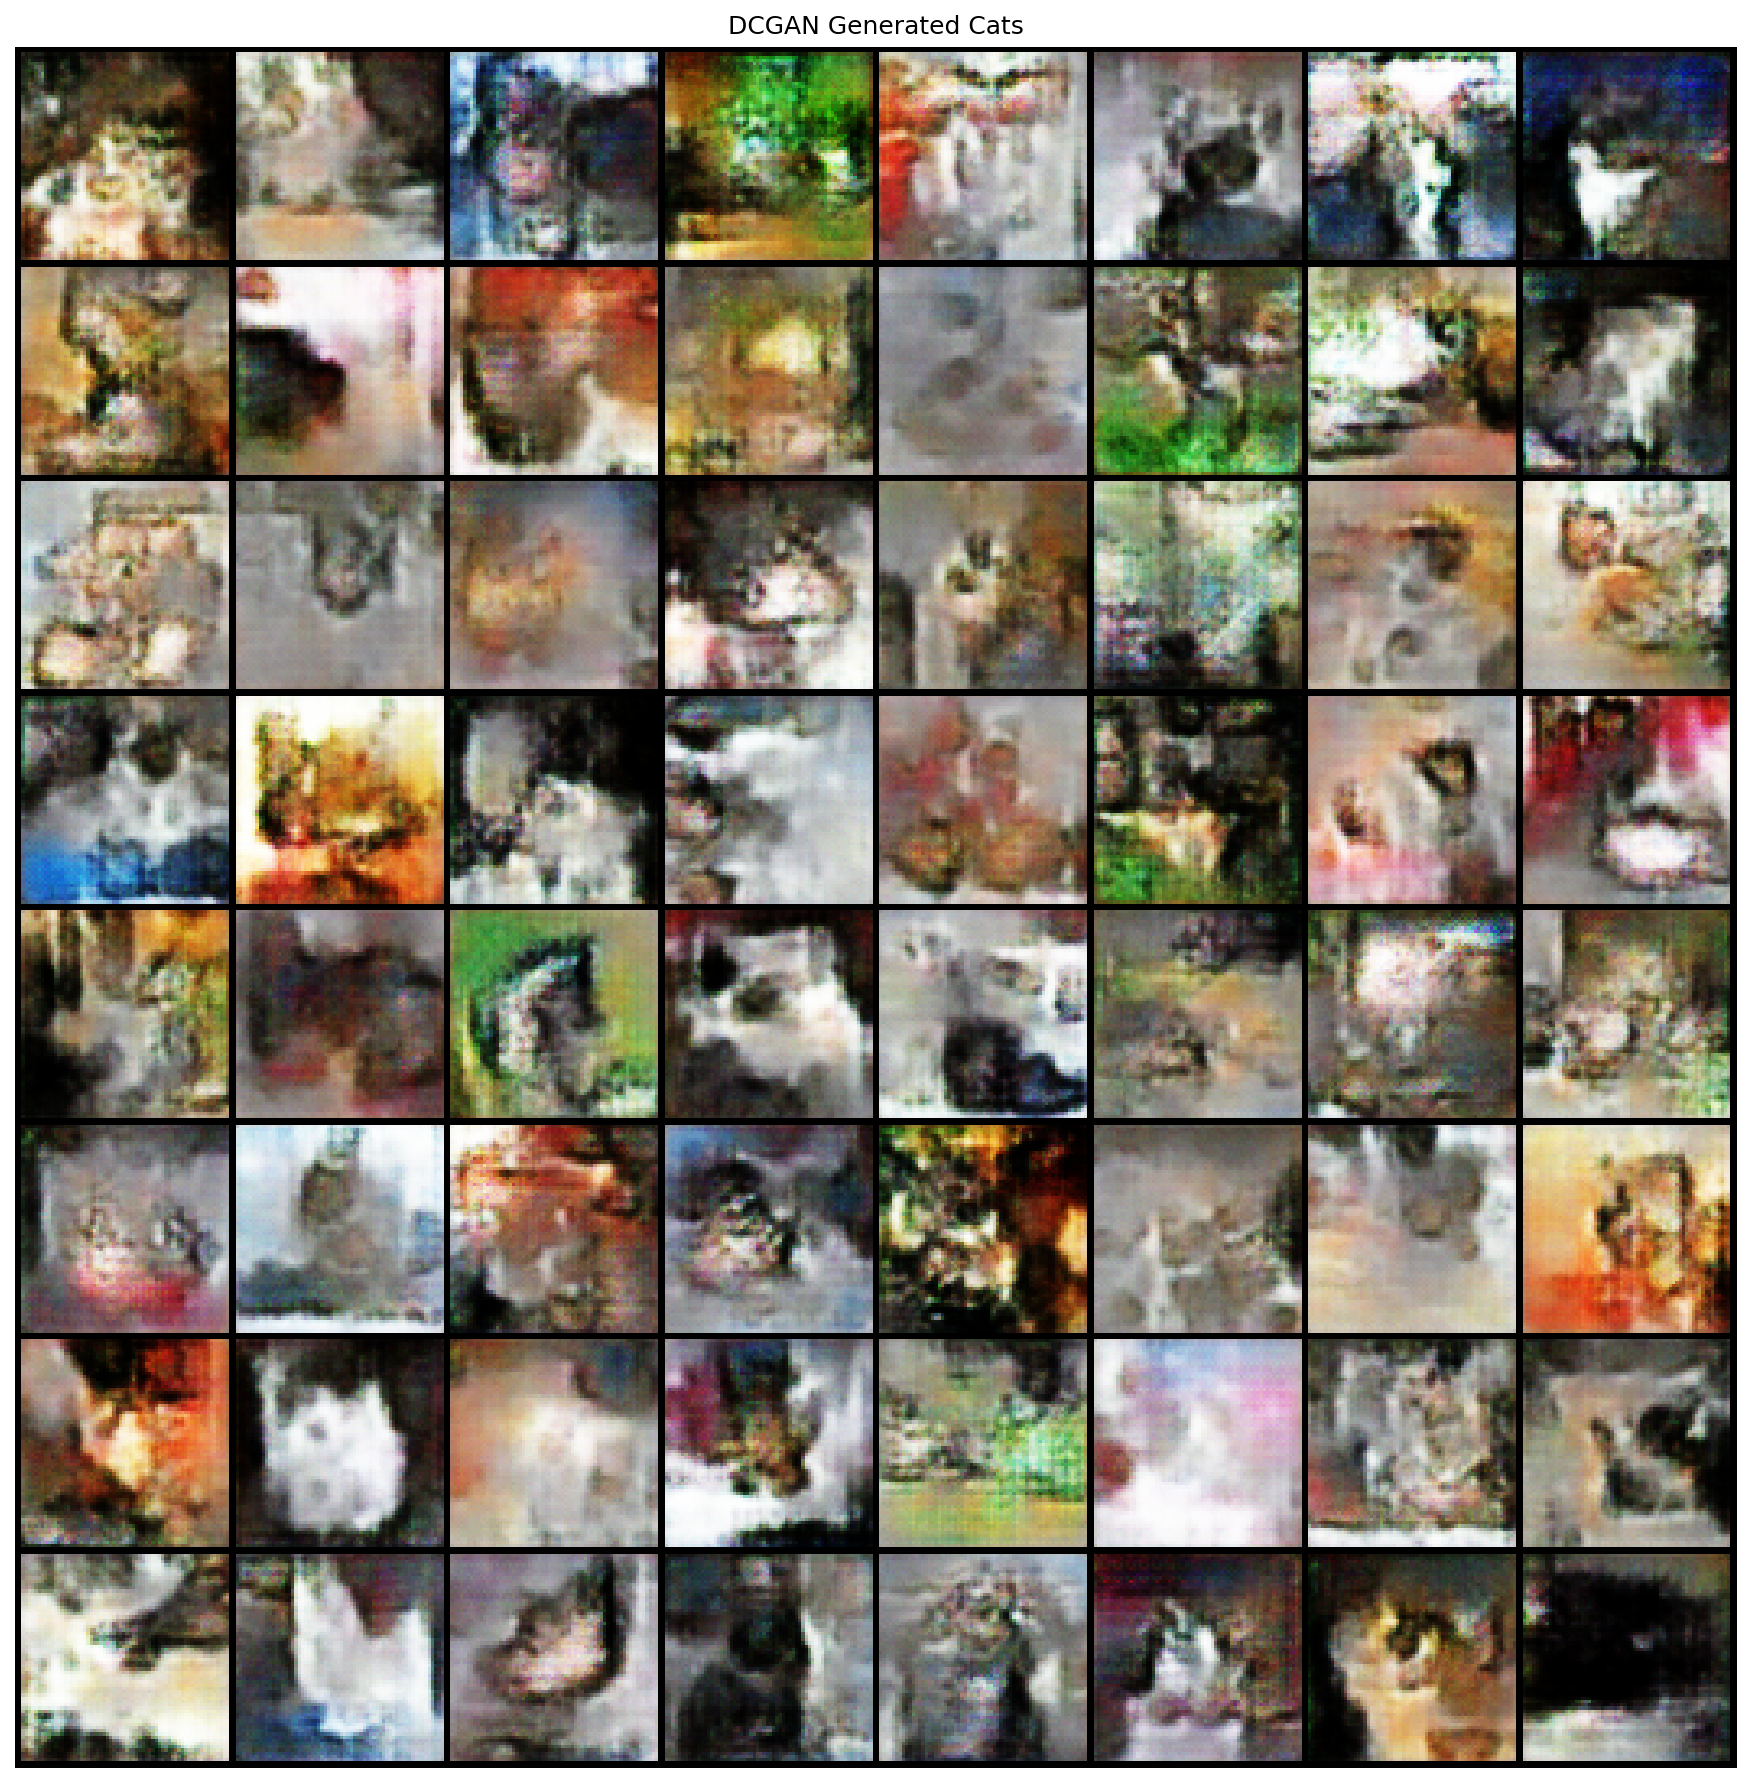

In [3]:
z = torch.randn(64, mc['z_dim'], device=device)
with torch.no_grad():
    samples = G(z)
save_image_grid(samples, '../outputs/dcgan/notebook_samples.png', nrow=8, title='DCGAN Generated Cats')
IPImage('../outputs/dcgan/notebook_samples.png')

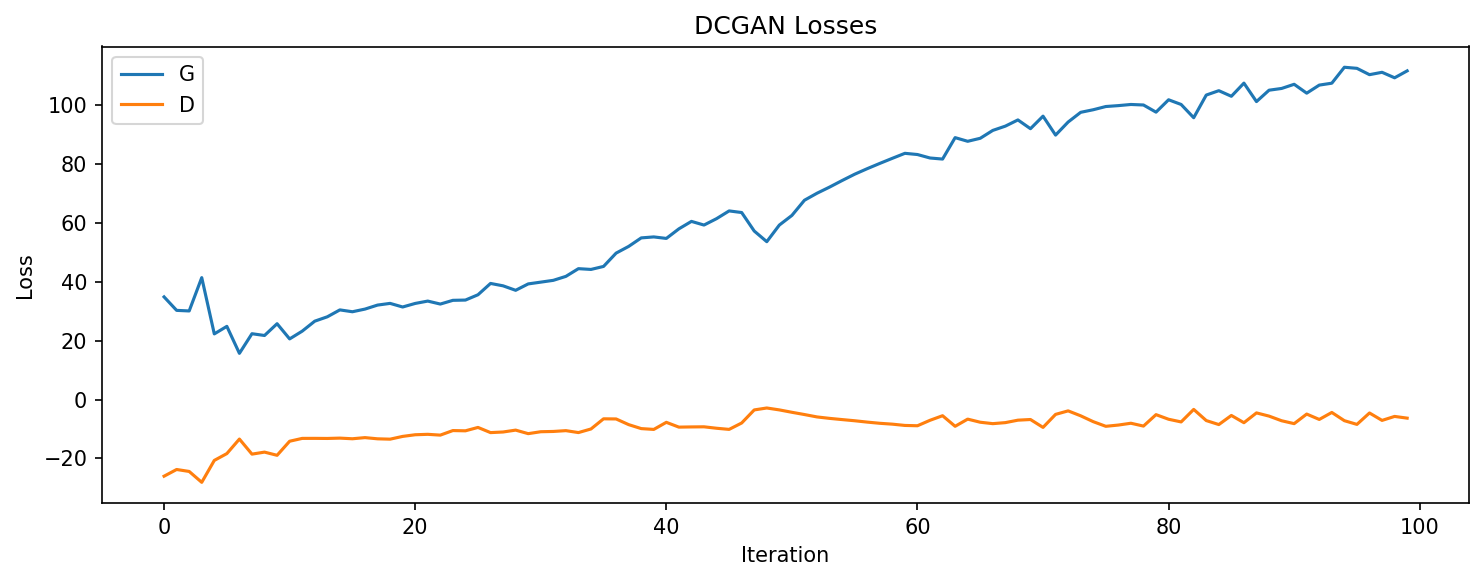

In [4]:
IPImage('../outputs/dcgan/losses.png')

In [5]:
loader = get_cat_loader('../data/cats', image_size=64, batch_size=64, num_workers=0, shuffle=False)
save_real_samples(loader, '../outputs/real_64', n_samples=5000)

save_samples(G, '../outputs/dcgan/fid_samples', n_samples=5000,
             batch_size=64, device=device, z_dim=mc['z_dim'])

fid = compute_fid('../outputs/real_64', '../outputs/dcgan/fid_samples')
print(f'DCGAN FID: {fid:.2f}')

Saved 5000 real images to ..\outputs\real_64
Saved 5000 images to ..\outputs\dcgan\fid_samples
DCGAN FID: 221.51


In [6]:
import json
import pandas as pd

with open('../outputs/ablation/dcgan_ablation_results.json') as f:
    abl = json.load(f)

zdim_rows = [
    {'z_dim': abl['z_dim=64']['z_dim'],         'FID': round(abl['z_dim=64']['fid'], 2),         'note': ''},
    {'z_dim': abl['z_dim=128 (base)']['z_dim'],  'FID': round(abl['z_dim=128 (base)']['fid'], 2), 'note': 'baseline'},
    {'z_dim': abl['z_dim=256']['z_dim'],         'FID': round(abl['z_dim=256']['fid'], 2),        'note': ''},
]
df_zdim = pd.DataFrame(zdim_rows)
print("z_dim ablation (50 epochs each):")
print(df_zdim.to_markdown(index=False))

lr_map = {'lr=1e-4': '1e-4', 'lr=2e-4 (base)': '2e-4 (baseline)', 'lr=4e-4': '4e-4', 'augmented': '2e-4 + augment'}
lr_rows = [
    {'lr': lr_map[k], 'FID': round(abl[k]['fid'], 2)}
    for k in ['lr=1e-4', 'lr=2e-4 (base)', 'lr=4e-4', 'augmented']
]
df_lr = pd.DataFrame(lr_rows)
print("\nLR and augmentation ablation (50 epochs each):")
print(df_lr.to_markdown(index=False))

z_dim ablation (50 epochs each):
|   z_dim |    FID | note     |
|--------:|-------:|:---------|
|      64 | 190.67 |          |
|     128 | 186.47 | baseline |
|     256 | 187.93 |          |

LR and augmentation ablation (50 epochs each):
| lr              |    FID |
|:----------------|-------:|
| 1e-4            | 218.46 |
| 2e-4 (baseline) | 183.37 |
| 4e-4            | 172.51 |
| 2e-4 + augment  | 215.95 |


In [7]:
import yaml
from src.evaluation.interpolation import dcgan_interpolation

zdim_configs = [
    ('z_dim=64',  '../checkpoints/ablation/dcgan_zdim64/ckpt_epoch0050.pt',       '../configs/dcgan_ablation_zdim64.yaml',       '../outputs/ablation/interp_zdim64.png'),
    ('z_dim=128', '../checkpoints/ablation/dcgan_zdim128_base/ckpt_epoch0050.pt', '../configs/dcgan_ablation_zdim128_base.yaml', '../outputs/ablation/interp_zdim128.png'),
    ('z_dim=256', '../checkpoints/ablation/dcgan_zdim256/ckpt_epoch0050.pt',      '../configs/dcgan_ablation_zdim256.yaml',      '../outputs/ablation/interp_zdim256.png'),
]

for name, ckpt, cfg_path, out in zdim_configs:
    set_seed(42)
    with open(cfg_path, encoding='utf-8') as f:
        cfg_z = yaml.safe_load(f)
    dcgan_interpolation(ckpt, cfg_z, out, device)

for name, _, _, out in zdim_configs:
    print(name)
    IPImage(out)

DCGAN interpolation strip saved to ../outputs/ablation/interp_zdim64.png
DCGAN interpolation strip saved to ../outputs/ablation/interp_zdim128.png
DCGAN interpolation strip saved to ../outputs/ablation/interp_zdim256.png
z_dim=64
z_dim=128
z_dim=256


## 4. Training-Bug Analysis: Why the Original DCGAN Underperformed

With `n_critic=5` and ~140 batches/epoch the original 100-epoch run gave the generator only **~2 800 gradient updates** (vs. ~14 000 for a vanilla DCGAN at the same wall-clock cost).  Each outer iteration consumed 5 real batches for D and only 1 for G, so the generator trained at 1/5 the expected rate.

Two corrected configurations are evaluated below:

| Config | GP | n_critic | epochs | G-steps | channels |
|---|---|---|---|---|---|
| `dcgan_fixed_vanilla` | No  | 1 | 150 | ~21 000 | 128 |
| `dcgan_fixed_wgangp`  | Yes | 2 | 200 | ~14 000 | 64  |


### 4a. Option A — Vanilla DCGAN, wider model (g_channels=128, 150 epochs)

In [8]:
import yaml
from src.models.dcgan import Generator
from src.utils.visualization import save_image_grid
from src.evaluation.fid import save_samples, compute_fid
from IPython.display import Image as IPImage

with open('../configs/dcgan_fixed_vanilla.yaml', encoding='utf-8') as f:
    cfg_va = yaml.safe_load(f)

CKPT_VA = '../checkpoints/dcgan_fixed_vanilla/ckpt_epoch0150.pt'
G_va = Generator(z_dim=cfg_va['model']['z_dim'],
                 base_channels=cfg_va['model']['g_channels'],
                 image_size=cfg_va['data']['image_size']).to(device)
state_va = torch.load(CKPT_VA, map_location=device)
G_va.load_state_dict(state_va['G'])
G_va.eval()
print(f"Loaded vanilla-fixed checkpoint from epoch {state_va['epoch']}")

Loaded vanilla-fixed checkpoint from epoch 150


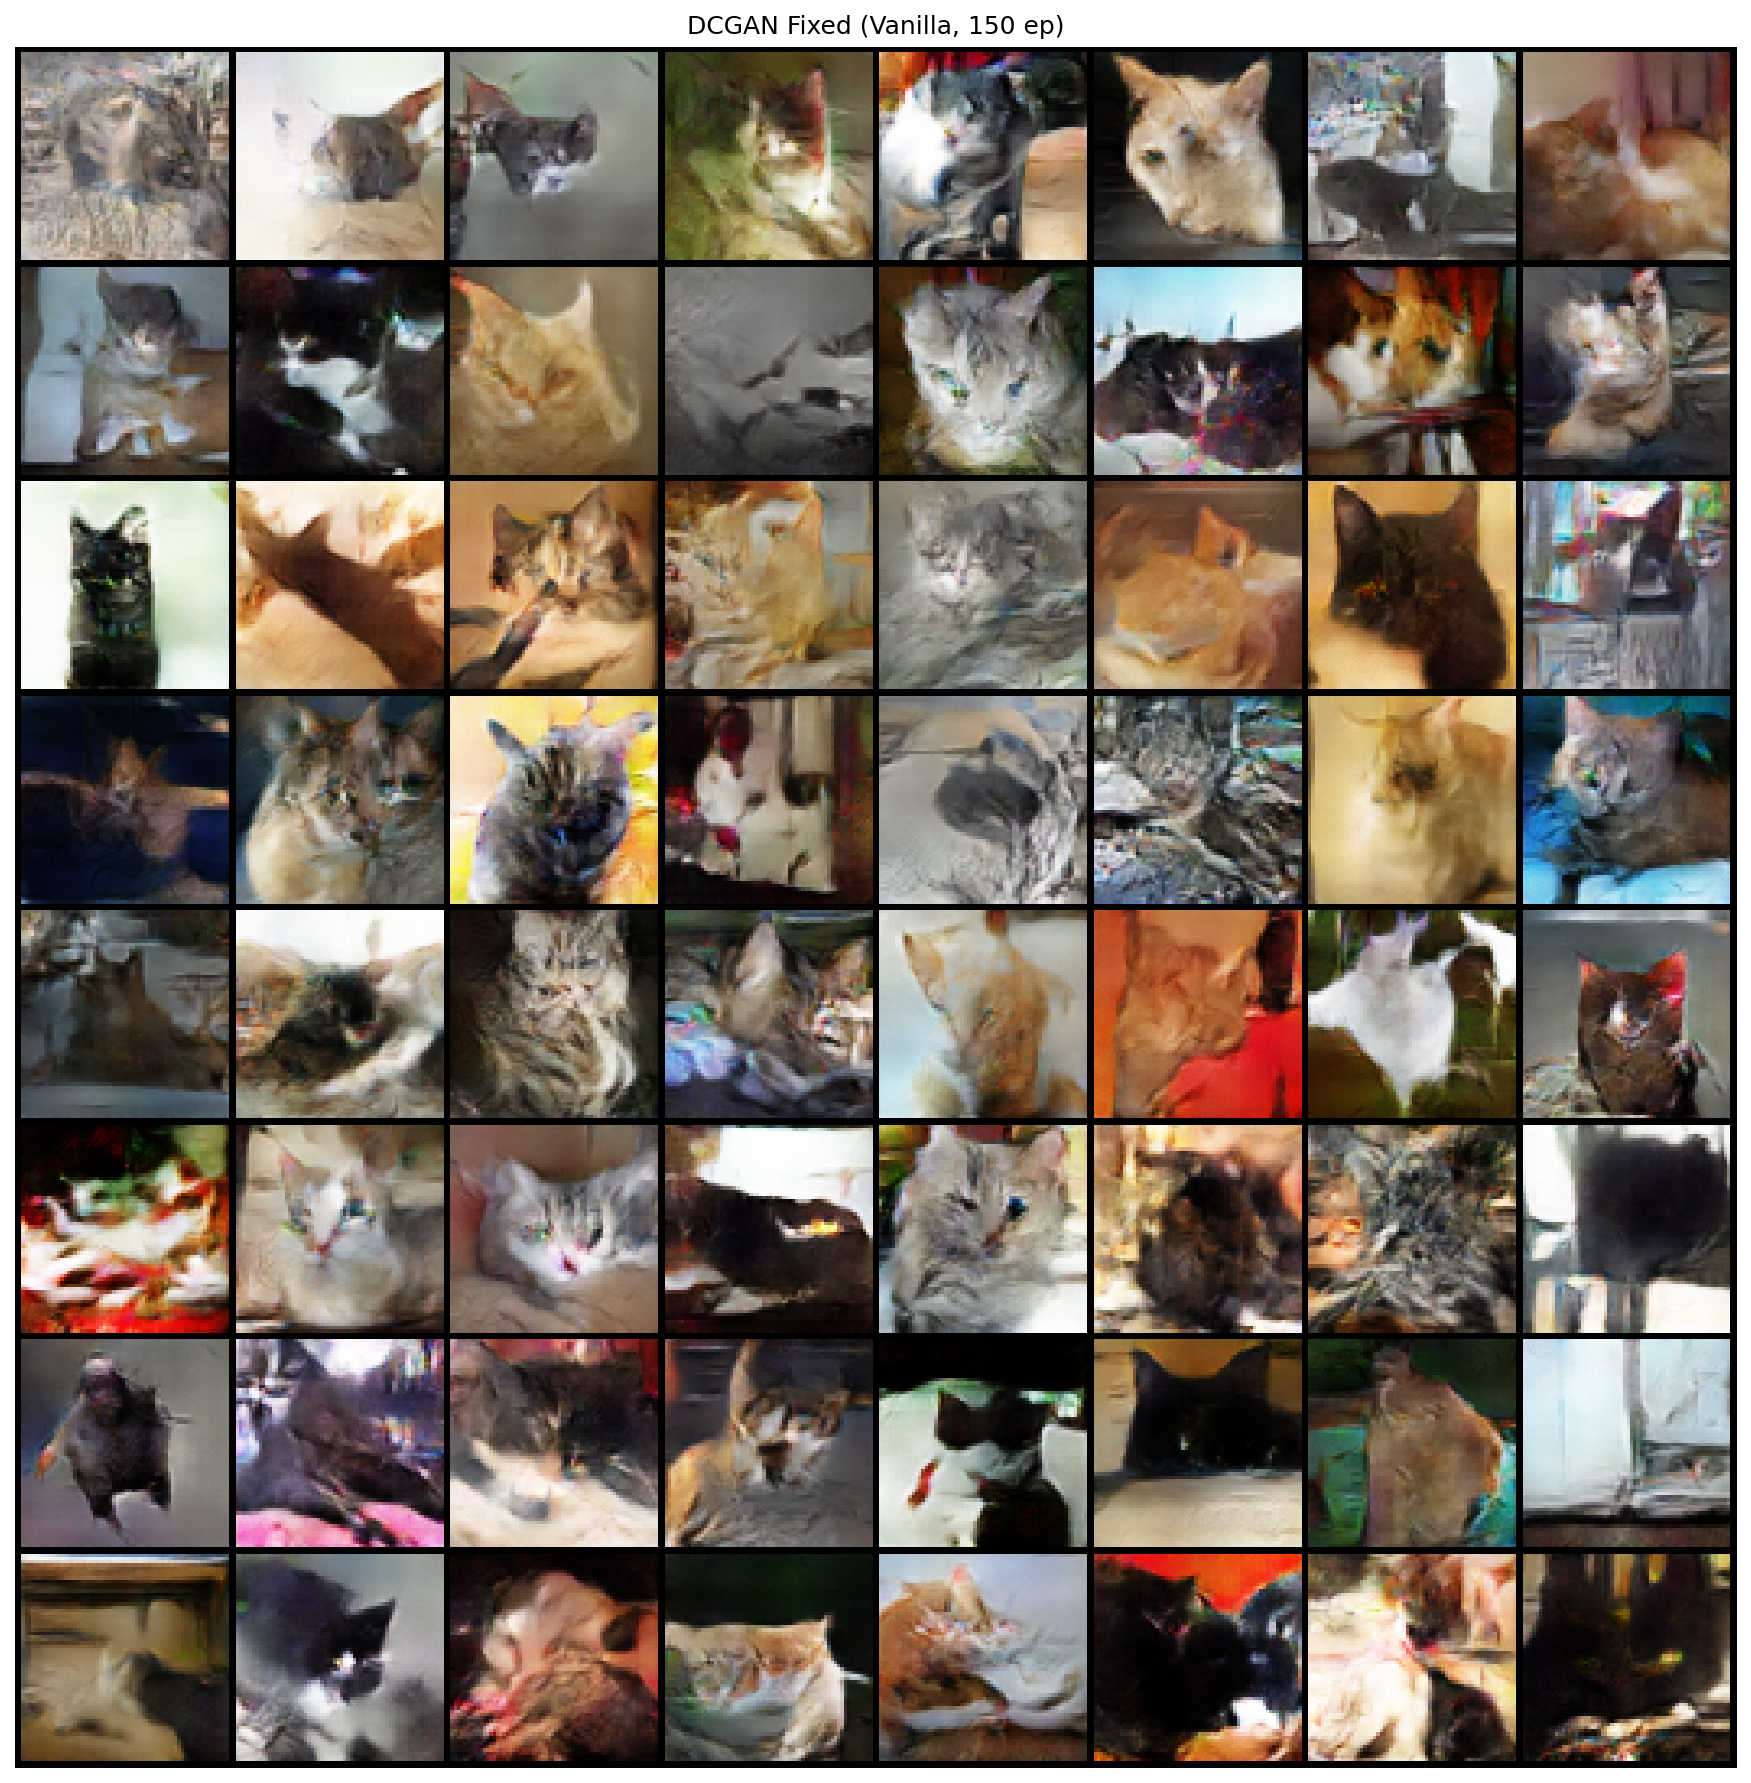

In [9]:
set_seed(42)
z = torch.randn(64, cfg_va['model']['z_dim'], device=device)
with torch.no_grad():
    samples_va = G_va(z)
save_image_grid(samples_va, '../outputs/dcgan_fixed_vanilla/notebook_samples.png',
                nrow=8, title='DCGAN Fixed (Vanilla, 150 ep)')
IPImage('../outputs/dcgan_fixed_vanilla/notebook_samples.png')

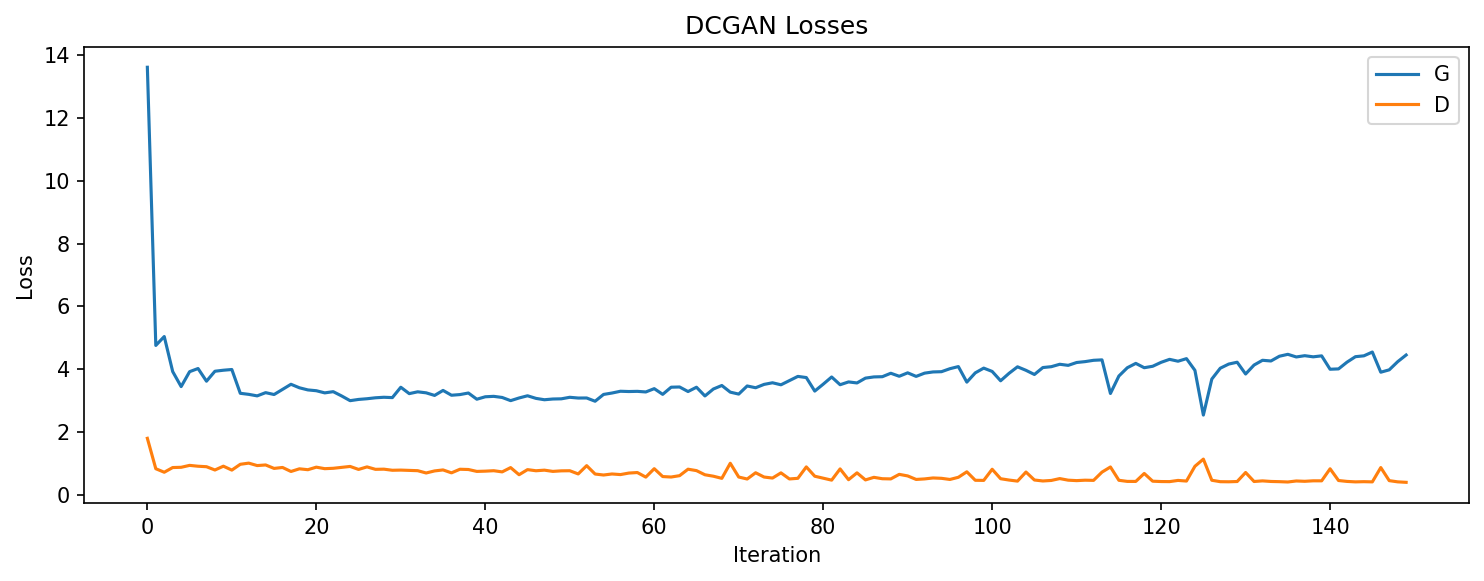

In [10]:
IPImage('../outputs/dcgan_fixed_vanilla/losses.png')

In [11]:
save_samples(G_va, '../outputs/dcgan_fixed_vanilla/fid_samples', n_samples=5000,
             batch_size=64, device=device, z_dim=cfg_va['model']['z_dim'])
fid_va = compute_fid('../outputs/real_64', '../outputs/dcgan_fixed_vanilla/fid_samples')
print(f'Fixed Vanilla DCGAN FID: {fid_va:.2f}  (original baseline: 221.51)')

Saved 5000 images to ..\outputs\dcgan_fixed_vanilla\fid_samples
Fixed Vanilla DCGAN FID: 98.91  (original baseline: 221.51)


### 4b. Option B — WGAN-GP, n_critic=2, lr=4e-4 (200 epochs)

In [12]:
with open('../configs/dcgan_fixed_wgangp.yaml', encoding='utf-8') as f:
    cfg_wp = yaml.safe_load(f)

CKPT_WP = '../checkpoints/dcgan_fixed_wgangp/ckpt_epoch0200.pt'
G_wp = Generator(z_dim=cfg_wp['model']['z_dim'],
                 base_channels=cfg_wp['model']['g_channels'],
                 image_size=cfg_wp['data']['image_size']).to(device)
state_wp = torch.load(CKPT_WP, map_location=device)
G_wp.load_state_dict(state_wp['G'])
G_wp.eval()
print(f"Loaded WGANGP-fixed checkpoint from epoch {state_wp['epoch']}")

Loaded WGANGP-fixed checkpoint from epoch 200


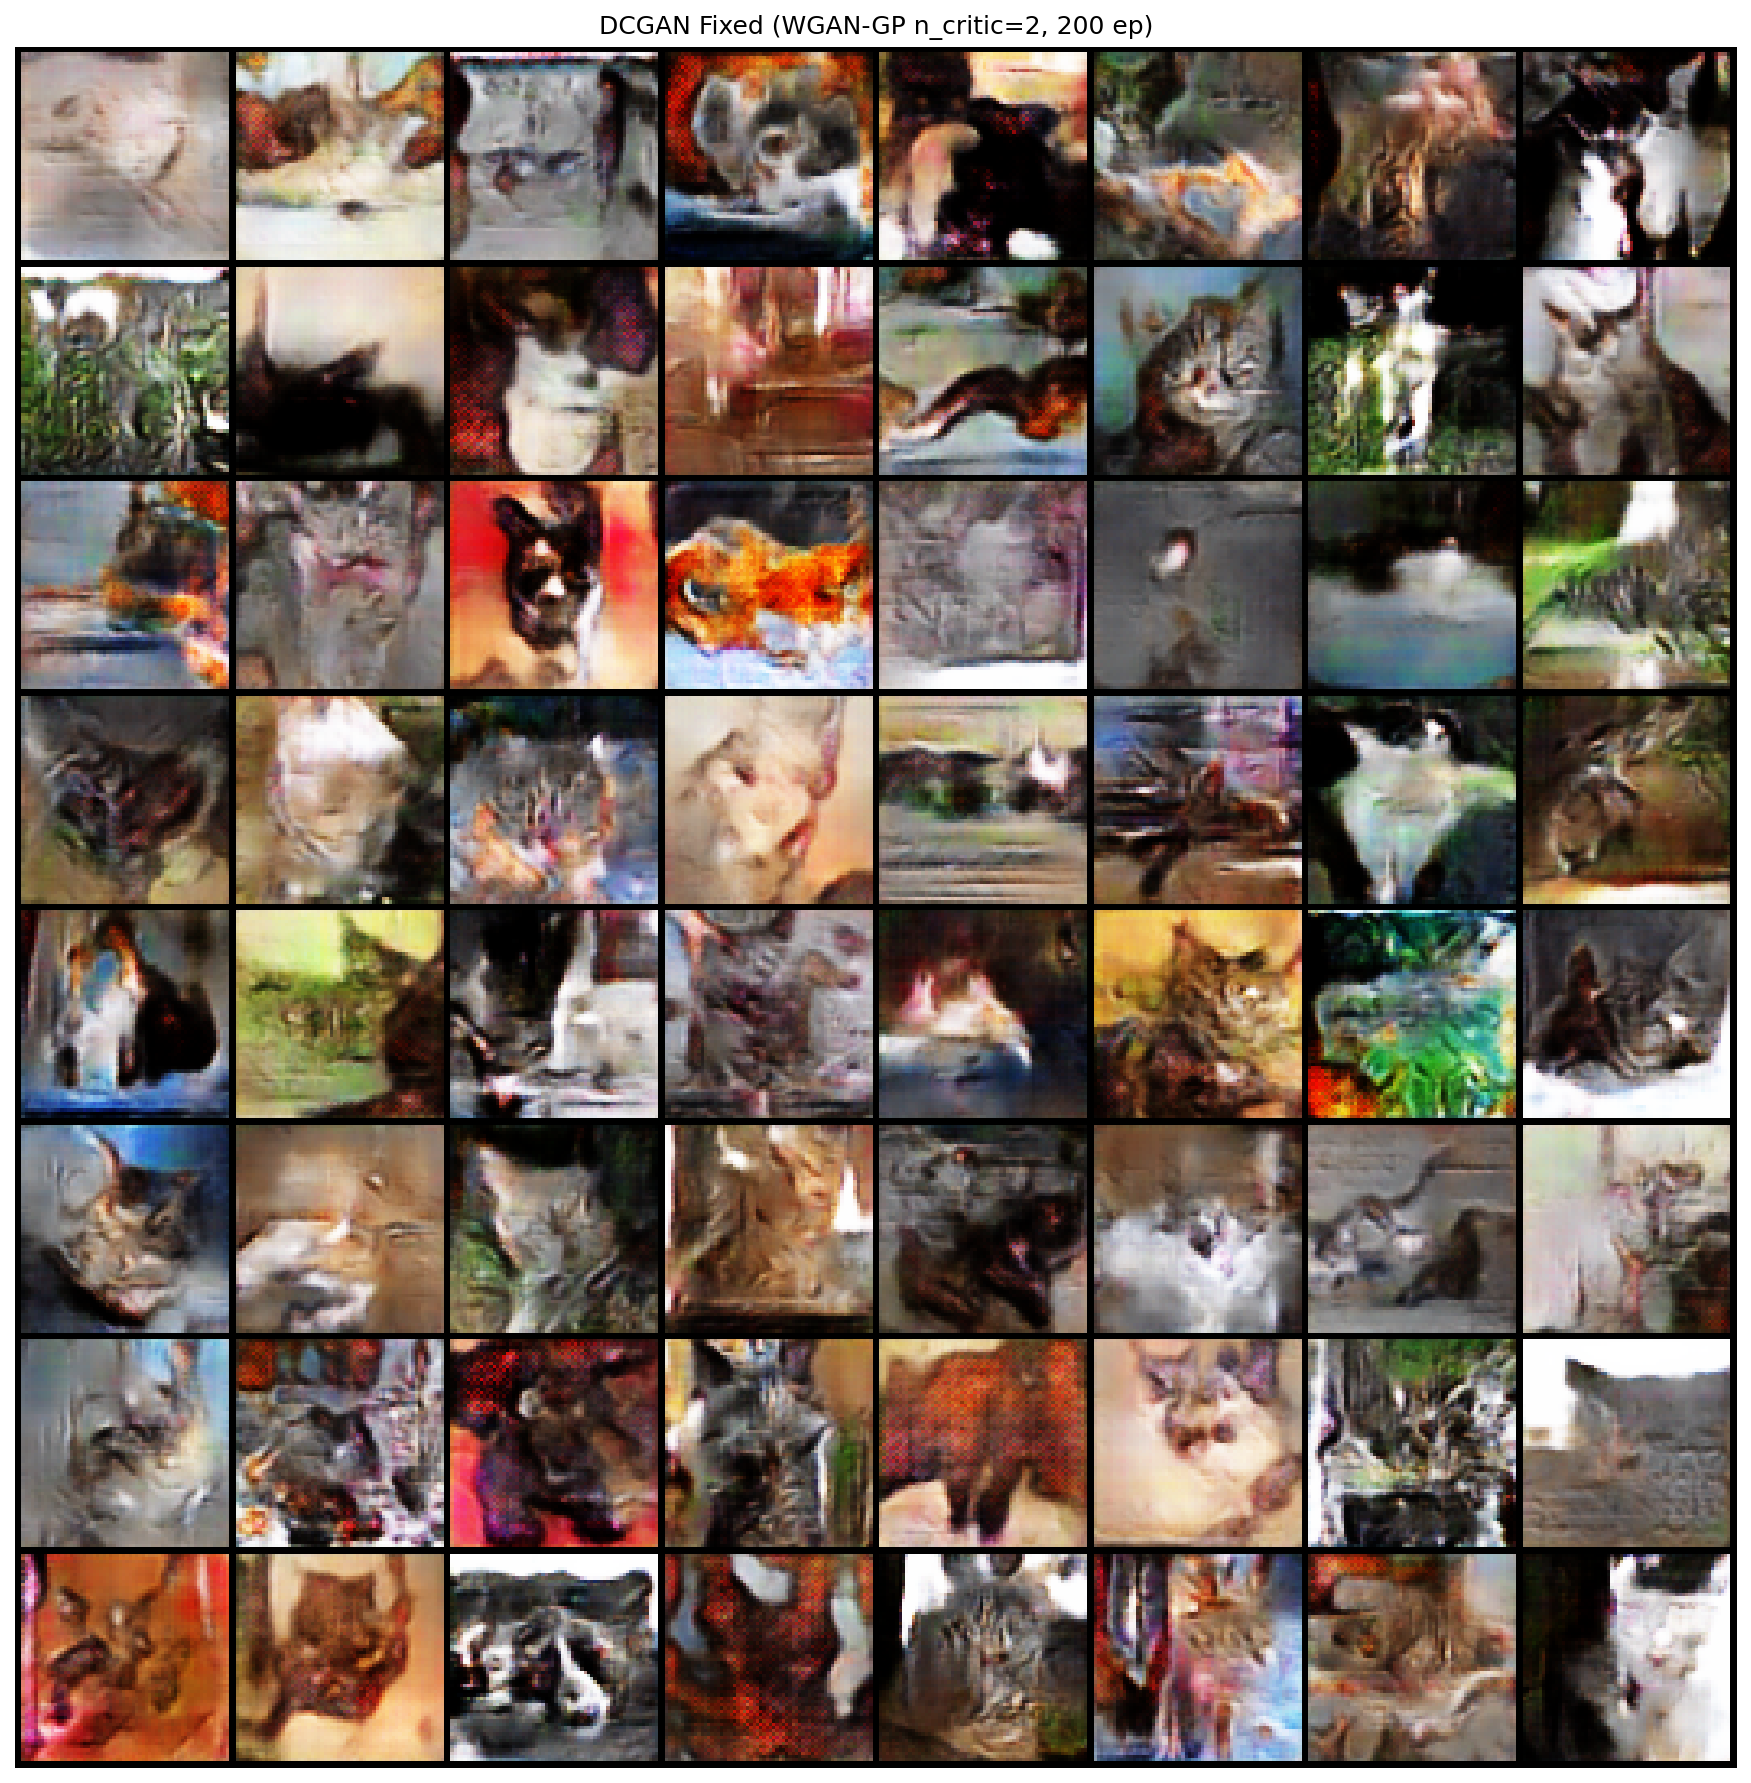

In [13]:
set_seed(42)
z = torch.randn(64, cfg_wp['model']['z_dim'], device=device)
with torch.no_grad():
    samples_wp = G_wp(z)
save_image_grid(samples_wp, '../outputs/dcgan_fixed_wgangp/notebook_samples.png',
                nrow=8, title='DCGAN Fixed (WGAN-GP n_critic=2, 200 ep)')
IPImage('../outputs/dcgan_fixed_wgangp/notebook_samples.png')

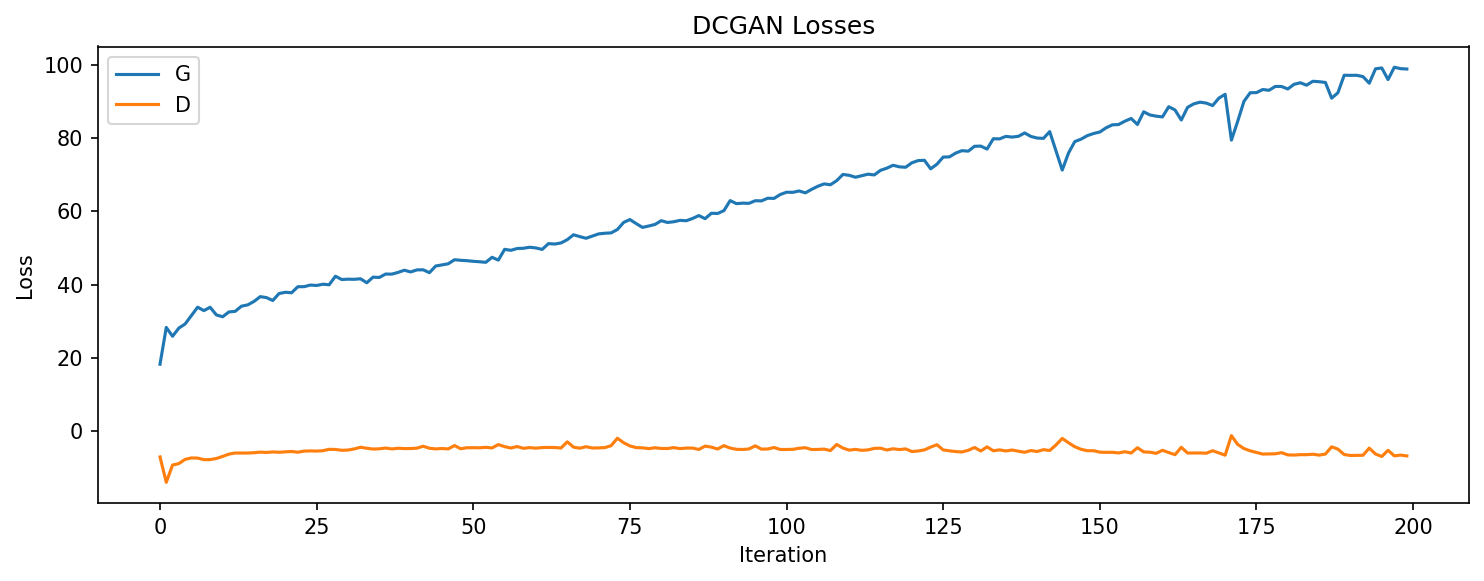

In [14]:
IPImage('../outputs/dcgan_fixed_wgangp/losses.png')

In [15]:
save_samples(G_wp, '../outputs/dcgan_fixed_wgangp/fid_samples', n_samples=5000,
             batch_size=64, device=device, z_dim=cfg_wp['model']['z_dim'])
fid_wp = compute_fid('../outputs/real_64', '../outputs/dcgan_fixed_wgangp/fid_samples')
print(f'Fixed WGAN-GP DCGAN FID: {fid_wp:.2f}  (original baseline: 221.51)')

Saved 5000 images to ..\outputs\dcgan_fixed_wgangp\fid_samples
Fixed WGAN-GP DCGAN FID: 157.72  (original baseline: 221.51)


### 4c. Summary comparison

In [16]:
import pandas as pd
rows = [
    {'Model': 'DCGAN original (WGAN-GP, n_critic=5, 100 ep)', 'FID': 221.51, 'G-steps': 2800},
    {'Model': 'Fixed Vanilla (n_critic=1, g_ch=128, 150 ep)',  'FID': fid_va,  'G-steps': 21000},
    {'Model': 'Fixed WGAN-GP (n_critic=2, lr=4e-4, 200 ep)',   'FID': fid_wp,  'G-steps': 14000},
]
df_cmp = pd.DataFrame(rows)
print(df_cmp.to_markdown(index=False))

| Model                                        |      FID |   G-steps |
|:---------------------------------------------|---------:|----------:|
| DCGAN original (WGAN-GP, n_critic=5, 100 ep) | 221.51   |      2800 |
| Fixed Vanilla (n_critic=1, g_ch=128, 150 ep) |  98.9072 |     21000 |
| Fixed WGAN-GP (n_critic=2, lr=4e-4, 200 ep)  | 157.715  |     14000 |


DCGAN interpolation strip saved to ../outputs/dcgan_fixed_vanilla/interpolation.png
DCGAN interpolation strip saved to ../outputs/dcgan_fixed_wgangp/interpolation.png
Vanilla fixed interpolation:


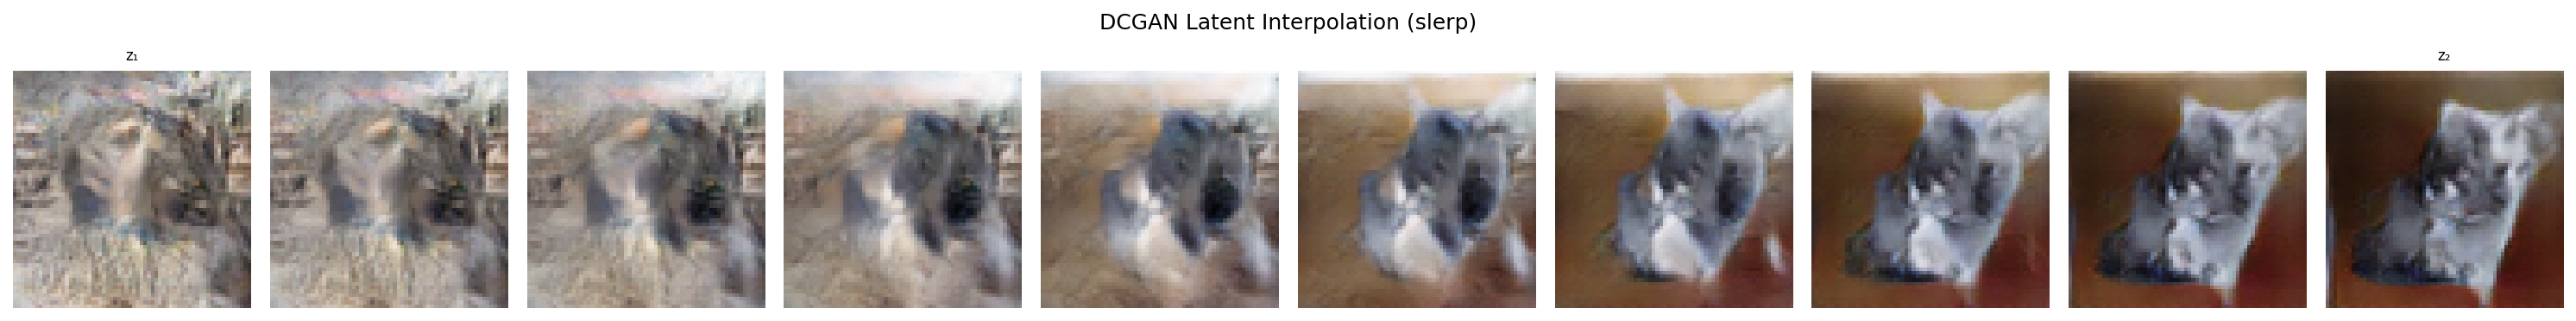

WGAN-GP fixed interpolation:


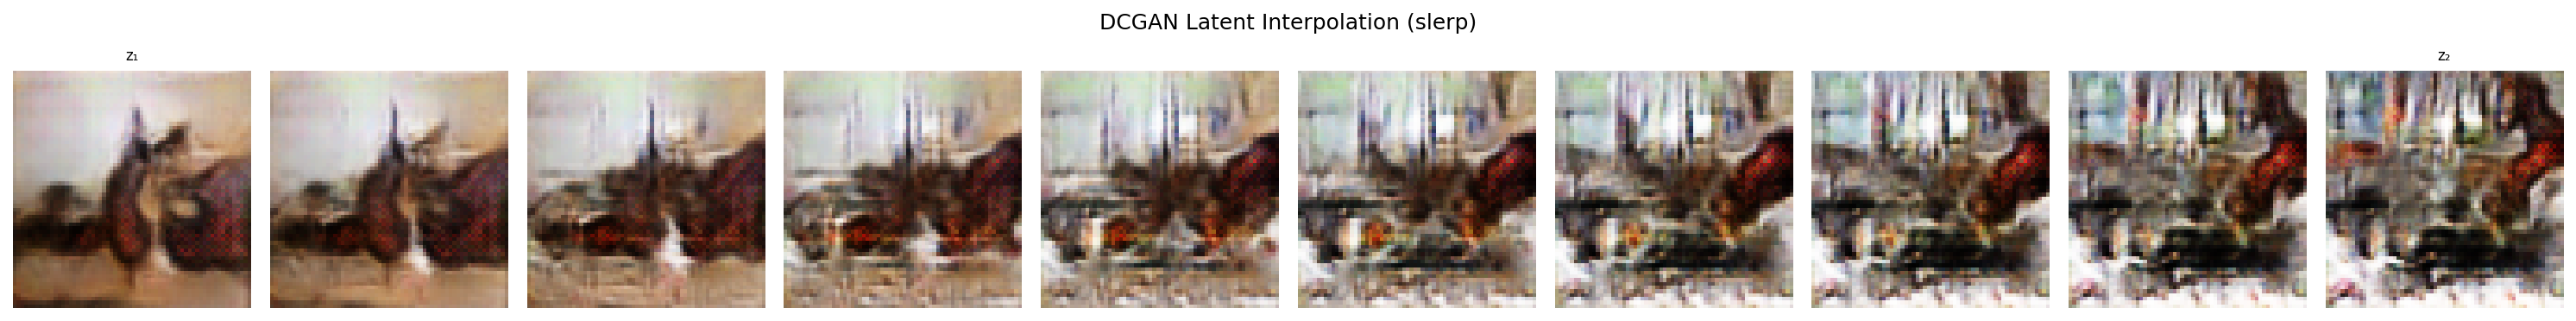

In [17]:
from src.evaluation.interpolation import dcgan_interpolation
set_seed(42)
dcgan_interpolation(CKPT_VA, cfg_va, '../outputs/dcgan_fixed_vanilla/interpolation.png', device)
dcgan_interpolation(CKPT_WP, cfg_wp, '../outputs/dcgan_fixed_wgangp/interpolation.png', device)
print('Vanilla fixed interpolation:')
display(IPImage('../outputs/dcgan_fixed_vanilla/interpolation.png'))
print('WGAN-GP fixed interpolation:')
display(IPImage('../outputs/dcgan_fixed_wgangp/interpolation.png'))